In [1]:
from datetime import datetime
import pandas as pd
import networkx as nx
from visualize_ean import plot_ean, draw_ean
from visualize_ean_plotly import plot_ean_plotly, draw_ean_plotly, show_ean
from build_ean import build_ean, add_headway_arcs, propagate, enrich_trip_data_with_boundaries
import headway_integration as hi
import numpy as np
from collections import defaultdict
import sys
from pathlib import Path as path
import report as rp

project_root = path(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from tools.schematic_map.routing import (build_route,get_signal_nodes_on_route,)
from infra_data.scenarios import load_network_csv, load_headways, get_scenario
from tools.RailML2trip_data.reassign_trip_id import reassign_trip_ids_by_departure
from tools.RailML2trip_data.add_side_nodes_to_trip_data import add_side_nodes_to_trip_data

# Import infrastructure and timetable, clean and prepare data

In [2]:
nodesDf = load_network_csv("nodes.csv", "node_id")
edgesDf = load_network_csv("edges.csv", "edge_id")
scenario = get_scenario()
scenario_dir = project_root / "results" / str(scenario)
scenario_dir.mkdir(parents=True, exist_ok=True)
trip_data = np.load(rf"C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau\tools\RailML2trip_data\trip_data_{scenario}.npy", allow_pickle=True).item()
headway_dict = load_headways()
selected_trips_sorted = np.array(list(trip_data.keys()))

In [3]:
trip_data = {
    train_id: [
        (station, arr_dt, dep_dt, True)
        for station, arr_dt, dep_dt in stops
    ]
    for train_id, stops in trip_data.items()
}

In [4]:
trip_data, ordered_old_ids = reassign_trip_ids_by_departure(trip_data)

In [5]:
routing_results = {}

for stop_col in ["stop_slow", "stop_fast"]:

    stops = nodesDf.index[(nodesDf[stop_col] == 1) & (nodesDf["y"] == 0)].tolist()

    for start, end in zip(stops[:-1], stops[1:]):

        routing_results[(start, end)] = build_route(nodesDf, edgesDf, start, end)
        routing_results[(end, start)] = build_route(nodesDf, edgesDf, end, start)

In [6]:
routes = {}
for trip_id, trip in trip_data.items():
    start, end = trip[0][0], trip[-1][0]
    routes[trip_id] = build_route(nodesDf, edgesDf, start, end)

In [7]:
trip_data_sides = add_side_nodes_to_trip_data(trip_data, nodesDf)

In [8]:
IG = hi.build_infra_graph(edgesDf)
chains, boundary_nodes = hi.extract_chains(IG, nodesDf)

print("Chains:", chains)
print("Boundary Nodes:", boundary_nodes)
trip_data_enriched = enrich_trip_data_with_boundaries(trip_data_sides, routes, nodesDf, boundary_nodes)

Chains: {('Dev_MAR_01', 'Dev_MAR_02'): ['Dev_MAR_01', 'Pa_I_MAR_31_side', 'MAR_side', 'Pa_I_MAR_32_side', 'Dev_MAR_02'], ('Dev_MAR_02', 'Dev_TEL_01'): ['Dev_MAR_02', 'PL06', 'Pr_I_MAR_52', 'Pa_E_MAR_62', 'PL06bis', 'Pr_I_MAR_72', 'Pr_E_MAR_02', 'IG_MAR', 'SG_MAR', 'HD_201_02', 'HD_201_04', 'HD_201_06', 'IG_GIU', 'SG_GIU', 'HD_201_08', 'Dev_HD201/08', 'IG_ART', 'SG_ART', 'IG_TEL', 'HD_201_10', 'SG_TEL', 'Pr_E_TEL_01', 'Pr_I_TEL_91', 'PL07', 'Pa_E_TEL_61', 'Pr_I_TEL_71', 'Dev_TEL_01'], ('Dev_LASA_01', 'Dev_ORIS_01'): ['Dev_LASA_01', 'Pa_I_LASA_31_side', 'LASA_side', 'Pa_I_LASA_32_side', 'Dev_LASA_02_side', 'Pr_I_LASA_52_side', 'Pa_I_LASA_62_side', 'PL29_side', 'Pr_I_LASA_72_side', 'Pa_E_LASA_82_side', 'Pr_E_LASA_02_side', 'HD_701_01_side', 'SblLasa46915_side', 'HD_701_03_side', 'Pr_E_ORIS_01_side', 'Dev_ORIS_01'], ('Dev_ORIS_01', 'Pa_ORIS_32'): ['Dev_ORIS_01', 'Pr_I_ORIS_71', 'PL30', 'Pa_ORIS_31', 'ORIS', 'Pa_ORIS_32'], ('Dev_LAC_01', 'Dev_LAC_02'): ['Dev_LAC_01', 'Pa_I_LAC_31_side', 'LA

In [9]:
# Remove opposite-direction headways on double-track chains

# --------------------------------------------------
# Step 1: Count how many infrastructure edges occupy
# each elementary pk interval
# --------------------------------------------------

pk_values = sorted(nodesDf["pk_rel"].unique())

interval_count = defaultdict(int)

for _, edge in edgesDf.iterrows():

    pk1 = nodesDf.loc[edge["node_from"], "pk_rel"]
    pk2 = nodesDf.loc[edge["node_to"], "pk_rel"]

    a, b = sorted((pk1, pk2))

    for left, right in zip(pk_values[:-1], pk_values[1:]):
        if left >= a and right <= b:
            interval_count[(left, right)] += 1


# --------------------------------------------------
# Step 2: Determine whether each chain is entirely
# on double track
# --------------------------------------------------

double_track_chains = set()

for chain_key, chain_nodes in chains.items():

    is_double = True

    for n1, n2 in zip(chain_nodes[:-1], chain_nodes[1:]):

        pk1 = nodesDf.loc[n1, "pk_rel"]
        pk2 = nodesDf.loc[n2, "pk_rel"]

        a, b = sorted((pk1, pk2))

        for left, right in zip(pk_values[:-1], pk_values[1:]):
            if left >= a and right <= b:
                if interval_count[(left, right)] < 2:
                    is_double = False
                    break

        if not is_double:
            break

    if is_double:
        double_track_chains.add(chain_key)


# --------------------------------------------------
# Step 3: Remove opposite-direction headways
# on double-track chains
# --------------------------------------------------

for key in list(headway_dict):

    chain_key, cat1, cat2 = key

    if chain_key in double_track_chains:

        opposite = (
            ("up" in cat1 and "down" in cat2)
            or
            ("down" in cat1 and "up" in cat2)
        )

        if opposite:
            del headway_dict[key]

# Build EAN, add headway constraints

In [10]:
min_dwell_by_station = {
    "ME": 0,
    "LAG": 30,
    "MAR": 30,
    "TEL": 30,
    "RAB": 30,
    "PLA": 30,
    "NAT": 60,
    "STA": 60,
    "CIA": 30,
    "CAB": 30,
    "LAC": 90,
    "COLD": 30,
    "SIL": 60,
    "LASA": 60,
    "ORIS": 30,
    "SPON": 30,
    "SLU": 30,
    "MAL": 0, 
}

In [11]:
constraints, skipped = hi.assemble_headway_constraints(trip_data_sides, trip_data_enriched, routes, nodesDf, chains, headway_dict)

G_scheduled = build_ean(
    trip_data_enriched,
    min_dwell_by_station=min_dwell_by_station,
)
G_scheduled = add_headway_arcs(G_scheduled, constraints)
assert nx.is_directed_acyclic_graph(G_scheduled), "graph must stay a DAG"

# Stochastic Perturbation

In [12]:
node_perturbations, edge_perturbations = hi.generate_perturbation_scenarios(G_scheduled,
    n_scenarios=100,
    entry_delay_mean=2*60,
    entry_delay_std=2*60,
    entry_delay_probability=0.4,
    running_delay_mean=1*60,
    running_delay_std=1*60,
    edge_perturbation_probability = 0.0,
    seed=42,
)

## Propagation

In [13]:
realized_graphs = []

for node_p, edge_p in zip(node_perturbations,edge_perturbations,):

    G_realized = propagate(G_scheduled,edge_perturbations=edge_p,node_perturbations=node_p,)
    realized_graphs.append(G_realized)

## Visualization

### Plotly

In [14]:
fig, ax = plot_ean_plotly(G_scheduled,nodesDf,edgesDf,title=f"Scenario {scenario}: Scheduled vs Perturbed Timetable",)

for G_realized in realized_graphs[72:74]:

    draw_ean_plotly(G_realized,nodesDf,ax,alpha=0.5,linewidth_scale=0.8,)


show_ean(fig,filename=scenario_dir / f"ean_visualization{scenario}.html",auto_open=True,)

EAN visualization written to: C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau\results\3e\ean_visualization3e.html


WindowsPath('C:/Users/LeoC/VSCodes/optimizationVinschgau/AusbauVinschgau/results/3e/ean_visualization3e.html')

# Punctuality indicators 

In [15]:
stats = rp.extract_statistics(realized_graphs)
delay_classification = rp.classify_arrival_delays(realized_graphs)
#print(delay_classification['active_headways'])

print(f"Average delayed (>3 min) arrivals in a day: {delay_classification['total']/len(realized_graphs)}")
print(f"Average primary delayed arrivals: {delay_classification['primary']/len(realized_graphs)}")
print(f"Average secondary delayed arrivals: {delay_classification['secondary']/len(realized_graphs)}")

print("\nSecondary delayed nodes:")
for delay in delay_classification["delays"]:
    if delay["classification"] == "secondary":
        print(
            f"realization={delay['realization']} "
            f"node={delay['node']} "
            f"train={delay['train']} "
            f"station={delay['station']} "
            f"delay={delay['delay_seconds'] / 60:.2f} min"
        )


Average delayed (>3 min) arrivals in a day: 28.99
Average primary delayed arrivals: 7.0
Average secondary delayed arrivals: 21.99

Secondary delayed nodes:
realization=0 node=(1, 'HD_801_07', 'arr', 33) train=1 station=HD_801_07 delay=3.05 min
realization=0 node=(1, 'SLU_side', 'arr', 34) train=1 station=SLU_side delay=3.04 min
realization=0 node=(2, 'Pa_ORIS_32', 'arr', 20) train=2 station=Pa_ORIS_32 delay=3.11 min
realization=0 node=(9, 'LAG', 'arr', 2) train=9 station=LAG delay=3.37 min
realization=0 node=(14, 'LAG', 'arr', 2) train=14 station=LAG delay=3.57 min
realization=0 node=(14, 'Dev_MAR_01', 'arr', 3) train=14 station=Dev_MAR_01 delay=3.13 min
realization=0 node=(14, 'MAR_side', 'arr', 4) train=14 station=MAR_side delay=3.11 min
realization=0 node=(18, 'Dev_SPON_02', 'arr', 3) train=18 station=Dev_SPON_02 delay=3.66 min
realization=0 node=(18, 'SPON', 'arr', 4) train=18 station=SPON delay=3.65 min
realization=0 node=(29, 'SLU', 'arr', 1) train=29 station=SLU delay=3.02 min
r

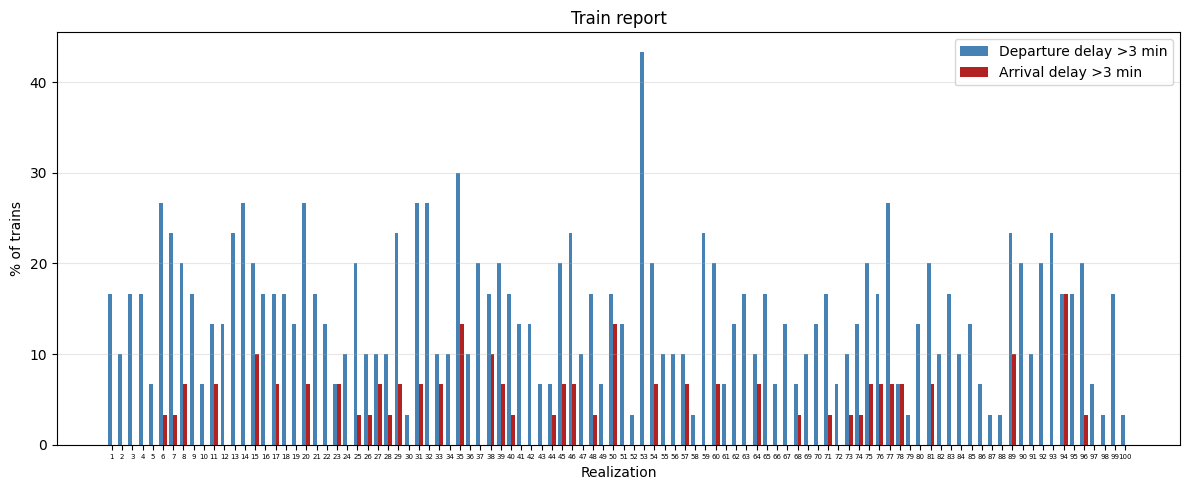

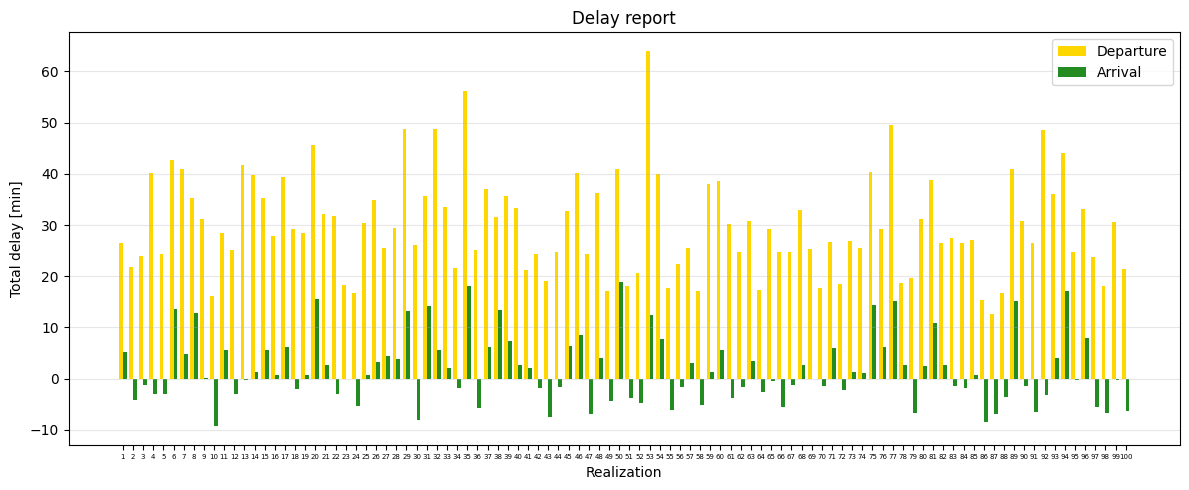

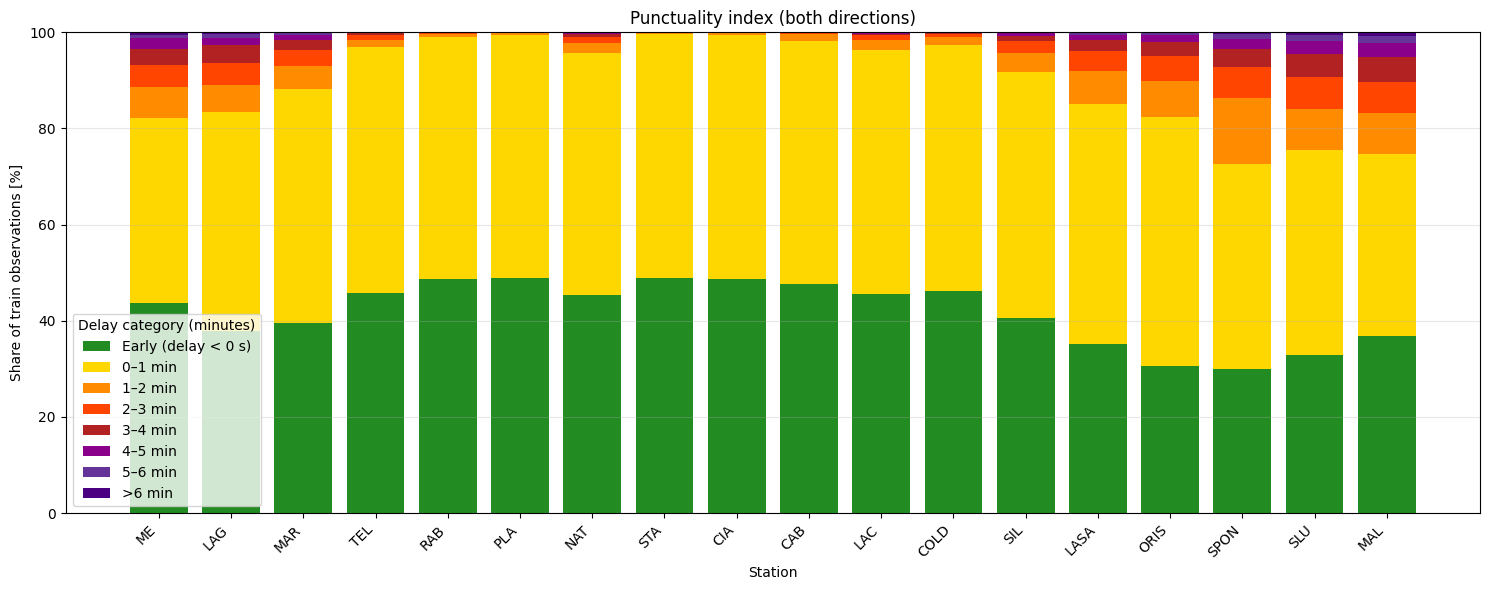

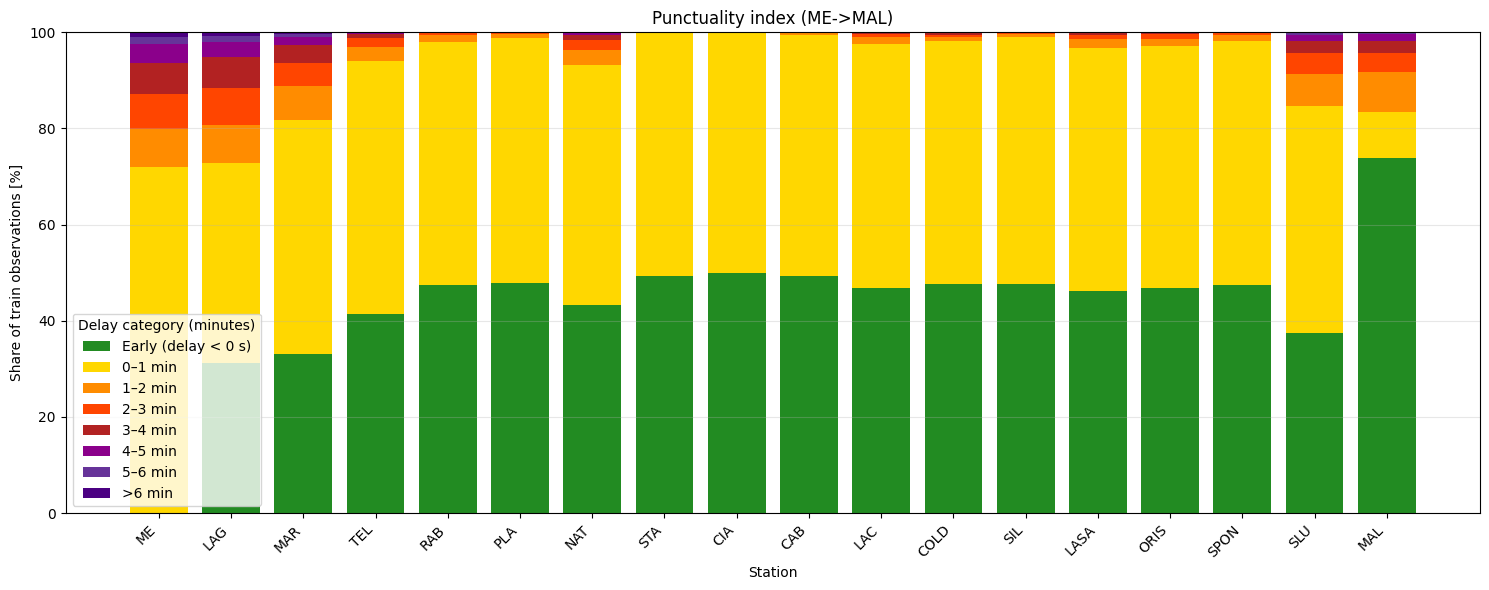

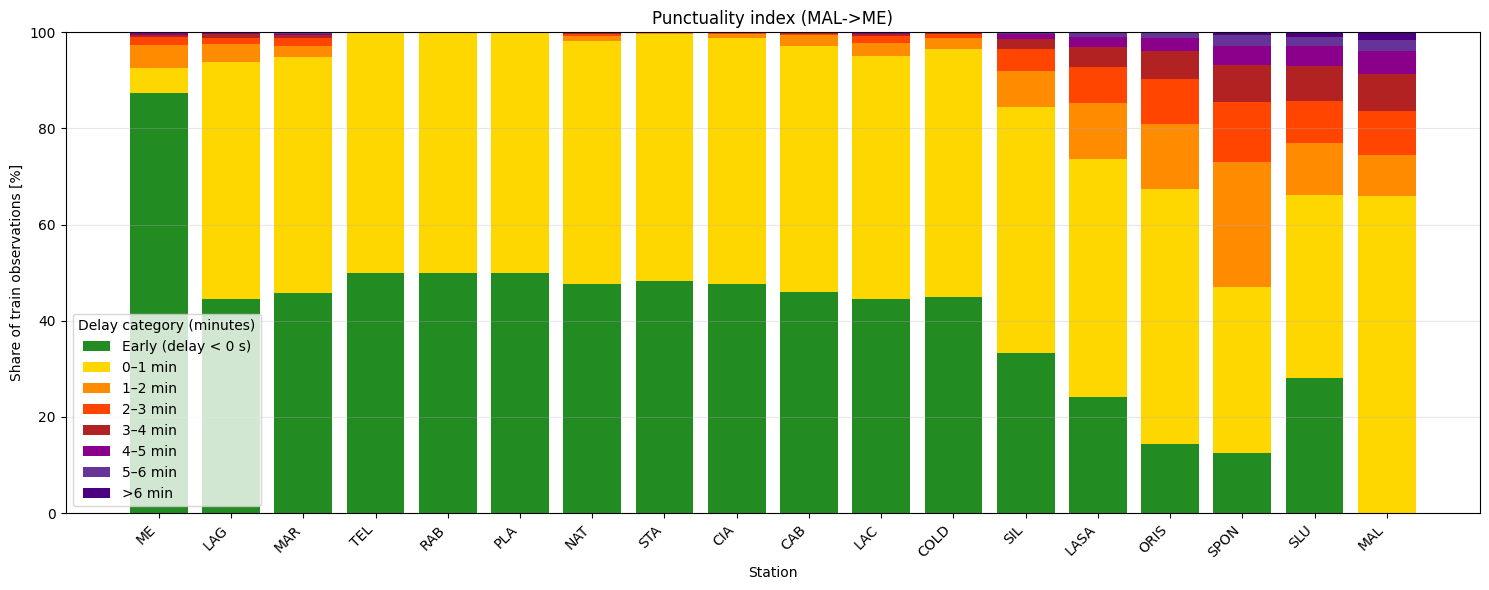

In [16]:
rp.plot_train_report(stats, output_dir=scenario_dir)
rp.plot_delay_report(stats, output_dir=scenario_dir)
rp.plot_punctuality_index(stats, output_dir=scenario_dir)
rp.plot_punctuality_index_me_to_mal(stats, output_dir=scenario_dir)
rp.plot_punctuality_index_mal_to_me(stats, output_dir=scenario_dir)

In [19]:
travel_report = rp.summarize_travel_time_report(G_scheduled, realized_graphs)
rp.print_travel_time_report(travel_report)

Scheduled timetable report
------------------------------------------------------------------------
 fast trains: scheduled 57.0 min/train (10 trains); realized avg 56.2 min
 slow trains: scheduled 83.3 min/train (20 trains); realized avg 82.3 min
------------------------------------------------------------------------


In [20]:
travel_report

{'scheduled': {'fast': {'mean_seconds': 3420.0,
   'mean_minutes': 57.0,
   'n_trains': 10},
  'slow': {'mean_seconds': 5001.0, 'mean_minutes': 83.35, 'n_trains': 20}},
 'realized': {'fast': {'mean_seconds': 3373.42584069857,
   'mean_minutes': 56.223764011642835,
   'n_observations': 1000},
  'slow': {'mean_seconds': 4939.903343223303,
   'mean_minutes': 82.33172238705505,
   'n_observations': 2000}},
 'train_types': {1: 'slow',
  2: 'fast',
  3: 'slow',
  4: 'fast',
  5: 'slow',
  6: 'slow',
  7: 'fast',
  8: 'slow',
  9: 'slow',
  10: 'fast',
  11: 'slow',
  12: 'slow',
  13: 'fast',
  14: 'slow',
  15: 'slow',
  16: 'fast',
  17: 'slow',
  18: 'slow',
  19: 'fast',
  20: 'slow',
  21: 'slow',
  22: 'fast',
  23: 'slow',
  24: 'slow',
  25: 'fast',
  26: 'slow',
  27: 'slow',
  28: 'fast',
  29: 'slow',
  30: 'slow'}}

In [ ]:
rp.plot_speed_matrices([G_scheduled], nodesDf, ("ME", "NAT", "LAC", "SIL", "LASA", "MAL"), output_dir=scenario_dir)

'rp.plot_speed_matrices([G_scheduled], nodesDf, ("ME", "NAT", "LAC", "SIL", "LASA", "MAL"), output_dir=scenario_dir)'

In [ ]:
rp.plot_speed_matrices(realized_graphs, nodesDf, ("ME", "NAT", "LAC", "SIL", "LASA", "MAL"), output_dir=scenario_dir)

'rp.plot_speed_matrices(realized_graphs, nodesDf, ("ME", "NAT", "LAC", "SIL", "LASA", "MAL"), output_dir=scenario_dir)'

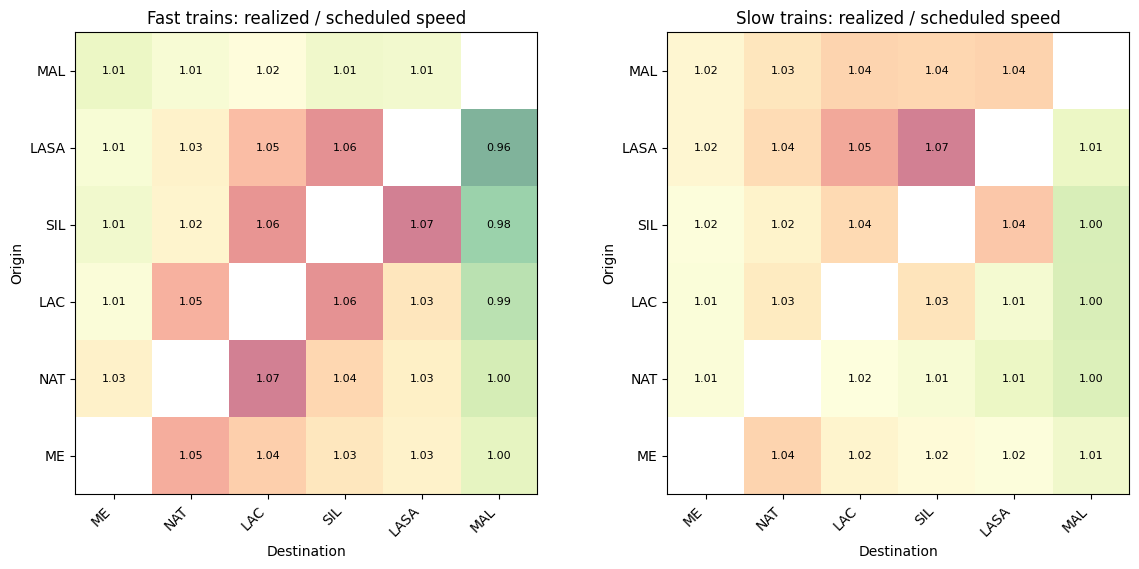

(array([[1.00582031, 1.01209528, 1.01813785, 1.00845126, 1.00979235,
                nan],
        [1.01238193, 1.02535539, 1.04639665, 1.06217144,        nan,
         0.96272532],
        [1.00911342, 1.02375414, 1.06062016,        nan, 1.07      ,
         0.97749677],
        [1.01365697, 1.05054936,        nan, 1.06196168, 1.03091042,
         0.98708912],
        [1.02568109,        nan, 1.0697629 , 1.03759459, 1.02691224,
         0.99613304],
        [       nan, 1.05176129, 1.04026152, 1.03070606, 1.02515784,
         1.00321068]]),
 array([[1.02222473, 1.03099042, 1.03872449, 1.03734668, 1.03921975,
                nan],
        [1.02215455, 1.03514794, 1.0538212 , 1.07041828,        nan,
         1.00578742],
        [1.01506227, 1.02476465, 1.03609369,        nan, 1.0429538 ,
         0.99763366],
        [1.01417663, 1.02891887,        nan, 1.03172306, 1.01080527,
         0.99782369],
        [1.0139013 ,        nan, 1.01593794, 1.01198439, 1.00598096,
         0.99912093

In [ ]:
rp.plot_speed_ratio_matrices(G_scheduled,realized_graphs,nodesDf,("ME", "NAT", "LAC", "SIL", "LASA", "MAL"),output_dir=scenario_dir)

In [ ]:
def calculate_operational(scheduled_graph, realized_graphs, nodesDf, stop_names):
    scheduled_fast, scheduled_slow = rp.build_speed_matrices(
        [scheduled_graph], nodesDf, stop_names
    )
    realized_fast, realized_slow = rp.build_speed_matrices(
        realized_graphs, nodesDf, stop_names
    )

    def ratio(scheduled, realized):
        valid = np.isfinite(scheduled) & np.isfinite(realized) & (realized > 0)
        return np.mean(scheduled[valid] / realized[valid])

    return {
        "fast": ratio(scheduled_fast, realized_fast),
        "slow": ratio(scheduled_slow, realized_slow),
    }

In [21]:
def calculate_nominal(travel_report):
    scheduled = travel_report["scheduled"]
    n_fast = scheduled["fast"]["n_trains"]
    n_slow = scheduled["slow"]["n_trains"]
    t_fast = scheduled["fast"]["mean_minutes"]
    t_slow = scheduled["slow"]["mean_minutes"]
    return (n_fast * t_fast + n_slow * t_slow) / (n_fast + n_slow)